In [222]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.rnd import FloatRandomSampling
from pymoo.optimize import minimize
from pymoo.termination import get_termination

In [ ]:
SEED = 42
np.random.seed(SEED)

# Winter:  CSV_PATH="hospital_week_feb.csv", TARGET_DATE="2025-02-05"
# Summer:  CSV_PATH="hospital_week_jul.csv", TARGET_DATE="2025-07-09"
CSV_PATH    = "hospital_week_feb.csv"
TARGET_DATE = "2025-02-08"

df_week = pd.read_csv(CSV_PATH, parse_dates=["timestamp"], index_col="timestamp")
df_hr = df_week.loc[TARGET_DATE].resample("1h").mean()
assert len(df_hr) == 24, f"Expected 24 hourly slots, got {len(df_hr)}"
print(f"Loaded {TARGET_DATE} from {CSV_PATH}")

tariff_p   = df_hr["tariff_p_per_kwh"].values
grid_ci    = df_hr["grid_ci_gco2_per_kwh"].values
outside_t  = df_hr["outside_temp_c"].values
base_hvac  = df_hr["ward_hvac_kw"].values
theatre_kw = df_hr["theatre_load_kw"].values
mri_kw     = df_hr["mri_load_kw"].values
base_kw    = df_hr["base_load_kw"].values

Loaded 2025-02-08 from hospital_week_feb.csv


In [ ]:
#Energy model
BASELINE_SETPOINT = 22.0
HVAC_SENSITIVITY  = 0.08

COMFORT_LOW  = 20.0
COMFORT_HIGH = 24.0
COMFORT_TOL  = 0.5

THERMAL_DECAY = 0.7
STORAGE_GAIN  = 0.5

def hvac_load_kw(setpoints):
    delta_sp = setpoints - BASELINE_SETPOINT
    base_demand = base_hvac * (1 + HVAC_SENSITIVITY * delta_sp)
    storage = np.zeros(len(setpoints))
    for t in range(1, len(setpoints)):
        storage[t] = THERMAL_DECAY*storage[t-1] + STORAGE_GAIN*delta_sp[t-1]
    offset = storage * base_hvac * HVAC_SENSITIVITY
    return np.maximum(base_demand - offset, 0.2 * base_hvac)

def comfort_breach(setpoints):
    """Worst hourly excursion outside the band (0 if fully compliant)."""
    below = np.maximum(COMFORT_LOW - setpoints, 0)
    above = np.maximum(setpoints - COMFORT_HIGH, 0)
    return float(np.max(below + above))

In [ ]:
# Deferrable load (laundry batch) 
DEFERRABLE_KW       = 40.0
DEFERRABLE_DURATION = 4
DEFERRABLE_EARLIEST = 0
DEFERRABLE_LATEST   = 22

def deferrable_profile(start_hour):
    start = int(np.clip(np.round(start_hour),
                        DEFERRABLE_EARLIEST, DEFERRABLE_LATEST))
    p = np.zeros(24)
    p[start:start + DEFERRABLE_DURATION] = DEFERRABLE_KW
    return p

In [ ]:
# Two-objective problem; comfort + setpoint-rate as hard constraints
class HospitalScheduleProblem(ElementwiseProblem):
    def __init__(self):
        super().__init__(
            n_var=25,            # 24 setpoints + 1 deferrable start
            n_obj=2,             # cost, carbon
            n_ieq_constr=24,     # 23 setpoint-rate + 1 comfort breach
            xl=np.concatenate([np.full(24, 18.0), [DEFERRABLE_EARLIEST]]),
            xu=np.concatenate([np.full(24, 26.0), [DEFERRABLE_LATEST]]),
        )

    def _evaluate(self, x, out, *args, **kwargs):
        x = np.asarray(x)
        sp = x[:24]
        defer_start = x[24]
        hvac = hvac_load_kw(sp)
        defer = deferrable_profile(defer_start)
        total = base_kw + hvac + theatre_kw + mri_kw + defer
        cost = (total * tariff_p / 100).sum()
        carbon = (total * grid_ci / 1000).sum()
        out["F"] = [cost, carbon]
        g = list(np.abs(np.diff(sp)) - 2.0)
        g.append(comfort_breach(sp) - COMFORT_TOL)
        out["G"] = np.array(g)

In [227]:
problem = HospitalScheduleProblem()
algorithm = NSGA2(pop_size=200, sampling=FloatRandomSampling(),
                  crossover=SBX(prob=0.9, eta=15), mutation=PM(eta=20))
termination = get_termination("n_gen", 200)
print("Running NSGA-II (200 pop x 200 gen)...")
res = minimize(problem, algorithm, termination,
               seed=SEED, verbose=False, save_history=False)
if res.F is None or len(res.F) == 0:
    raise RuntimeError("No feasible schedule found: the modelled plant "
                       "cannot hold the comfort band in this scenario, "
                       "which is itself a reportable finding.")
print(f"Feasible Pareto front size: {len(res.F)} solutions")

Running NSGA-II (200 pop x 200 gen)...
Feasible Pareto front size: 13 solutions


In [ ]:
pareto = pd.DataFrame(res.F, columns=["cost_gbp", "carbon_kg"])
sched  = pd.DataFrame(res.X, columns=[f"var_{h:02d}" for h in range(25)])
pd.concat([pareto, sched], axis=1).to_csv("pareto_front.csv", index=False)
idx_cheap = pareto["cost_gbp"].idxmin()
idx_green = pareto["carbon_kg"].idxmin()
print("\nTwo extreme compliant schedules")
for lab, i in [("Cheapest", idx_cheap), ("Greenest", idx_green)]:
    f = pareto.loc[i]
    print(f"  {lab:9s}  GBP {f.cost_gbp:6.2f}   {f.carbon_kg:6.2f} kgCO2")


--- Two extreme compliant schedules ---
  Cheapest   GBP 329.17   376.10 kgCO2
  Greenest   GBP 338.25   372.78 kgCO2


In [ ]:
# Baseline A: fixed-setpoint operation, no signal awareness 
BASELINE_DEFER_HOUR = 12
baseline_sp = np.full(24, BASELINE_SETPOINT)
baseline_total = (base_kw + hvac_load_kw(baseline_sp) + theatre_kw
                  + mri_kw + deferrable_profile(BASELINE_DEFER_HOUR))
baseline_cost = (baseline_total * tariff_p / 100).sum()
baseline_carbon = (baseline_total * grid_ci / 1000).sum()
print(f"Baseline A (22C flat, laundry {BASELINE_DEFER_HOUR}:00):")
print(f"  GBP {baseline_cost:.2f}   {baseline_carbon:.2f} kgCO2")
cost_saving = 100*(baseline_cost - pareto.loc[idx_cheap,"cost_gbp"])/baseline_cost
carb_saving = 100*(baseline_carbon - pareto.loc[idx_green,"carbon_kg"])/baseline_carbon
print(f"\n  Cost reduction (cheapest compliant):   {cost_saving:.1f}%")
print(f"  Carbon reduction (greenest compliant): {carb_saving:.1f}%")

Baseline A (22C flat, laundry 12:00):
  GBP 347.41   417.41 kgCO2

  Cost reduction (cheapest compliant):   5.3%
  Carbon reduction (greenest compliant): 10.7%


Saved pareto_front.png


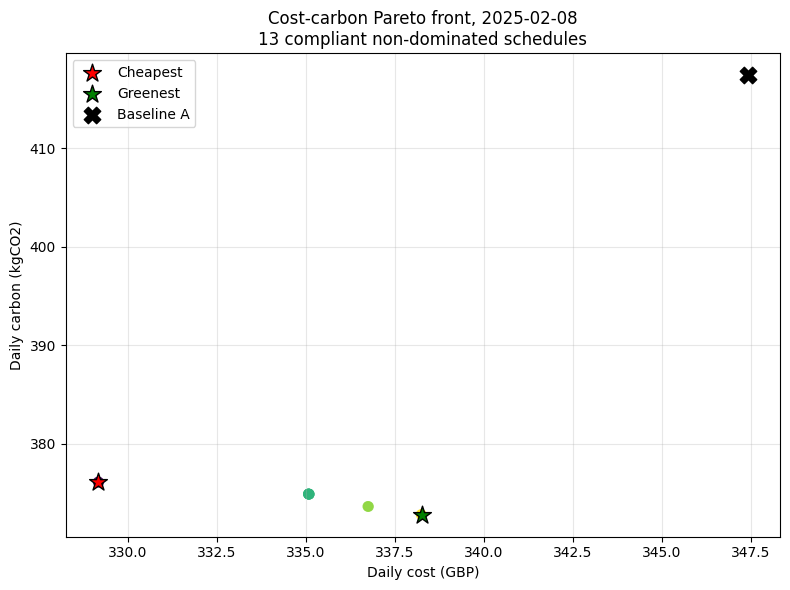

In [ ]:
# Figure 1: 2D Pareto front (all points clinically compliant)
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(pareto["cost_gbp"], pareto["carbon_kg"],
           c=pareto["cost_gbp"], cmap="viridis", s=45, alpha=0.85)
ax.scatter(pareto.loc[idx_cheap,"cost_gbp"], pareto.loc[idx_cheap,"carbon_kg"],
           color="red", s=180, marker="*", edgecolors="k",
           label="Cheapest", zorder=5)
ax.scatter(pareto.loc[idx_green,"cost_gbp"], pareto.loc[idx_green,"carbon_kg"],
           color="green", s=180, marker="*", edgecolors="k",
           label="Greenest", zorder=5)
ax.scatter(baseline_cost, baseline_carbon, color="black", s=140,
           marker="X", label="Baseline A", zorder=5)
ax.set_xlabel("Daily cost (GBP)")
ax.set_ylabel("Daily carbon (kgCO2)")
ax.set_title(f"Cost-carbon Pareto front, {TARGET_DATE}\n"
             f"{len(res.F)} compliant non-dominated schedules")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("pareto_front.png", dpi=150, bbox_inches="tight")
print("Saved pareto_front.png")

Saved schedules.png


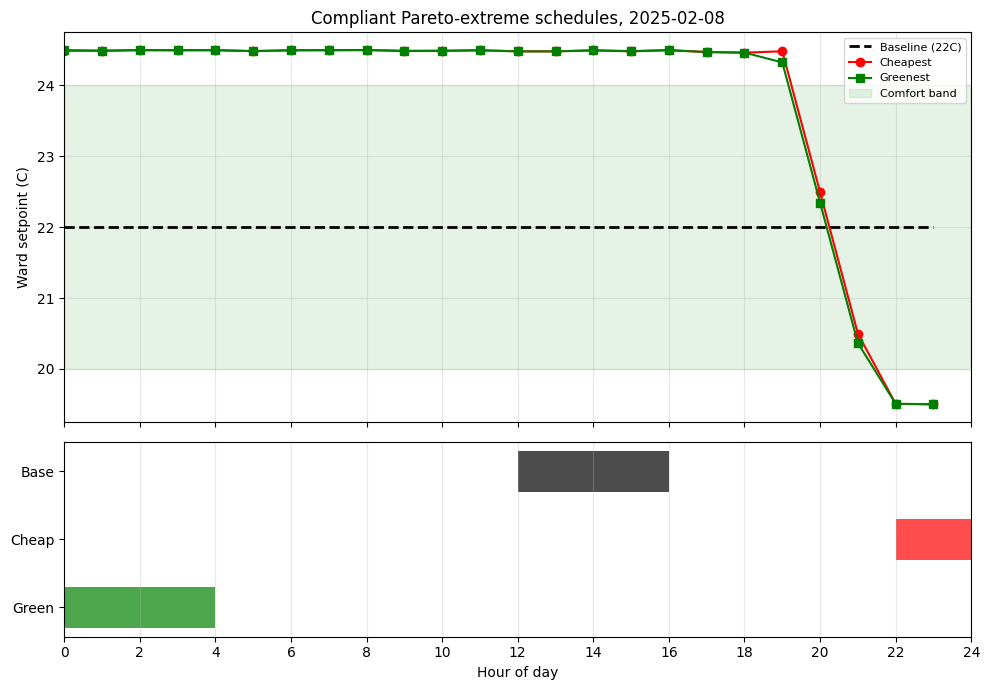

In [ ]:
# Figure 2: extreme schedules + deferrable timing 
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True,
                                gridspec_kw={"height_ratios": [2, 1]})
hrs = np.arange(24)
ax1.plot(hrs, baseline_sp, "k--", lw=2, label="Baseline (22C)")
ax1.plot(hrs, res.X[idx_cheap][:24], "r-o", label="Cheapest")
ax1.plot(hrs, res.X[idx_green][:24], "g-s", label="Greenest")
ax1.axhspan(COMFORT_LOW, COMFORT_HIGH, alpha=0.1, color="green",
            label="Comfort band")
ax1.set_ylabel("Ward setpoint (C)")
ax1.set_title(f"Compliant Pareto-extreme schedules, {TARGET_DATE}")
ax1.legend(loc="upper right", fontsize=8); ax1.grid(alpha=0.3)

def block(ax, h, y, c, lab):
    ax.barh(y, DEFERRABLE_DURATION, left=int(np.round(h)),
            height=0.6, color=c, alpha=0.7, label=lab)
block(ax2, BASELINE_DEFER_HOUR,  2, "black", "Baseline (12:00)")
block(ax2, res.X[idx_cheap][24], 1, "red",   "Cheapest")
block(ax2, res.X[idx_green][24], 0, "green", "Greenest")
ax2.set_yticks([0,1,2]); ax2.set_yticklabels(["Green","Cheap","Base"])
ax2.set_xlabel("Hour of day"); ax2.set_xlim(0, 24)
ax2.set_xticks(range(0, 25, 2)); ax2.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.savefig("schedules.png", dpi=150, bbox_inches="tight")
print("Saved schedules.png")

Saved baseline_vs_best.png
Done.


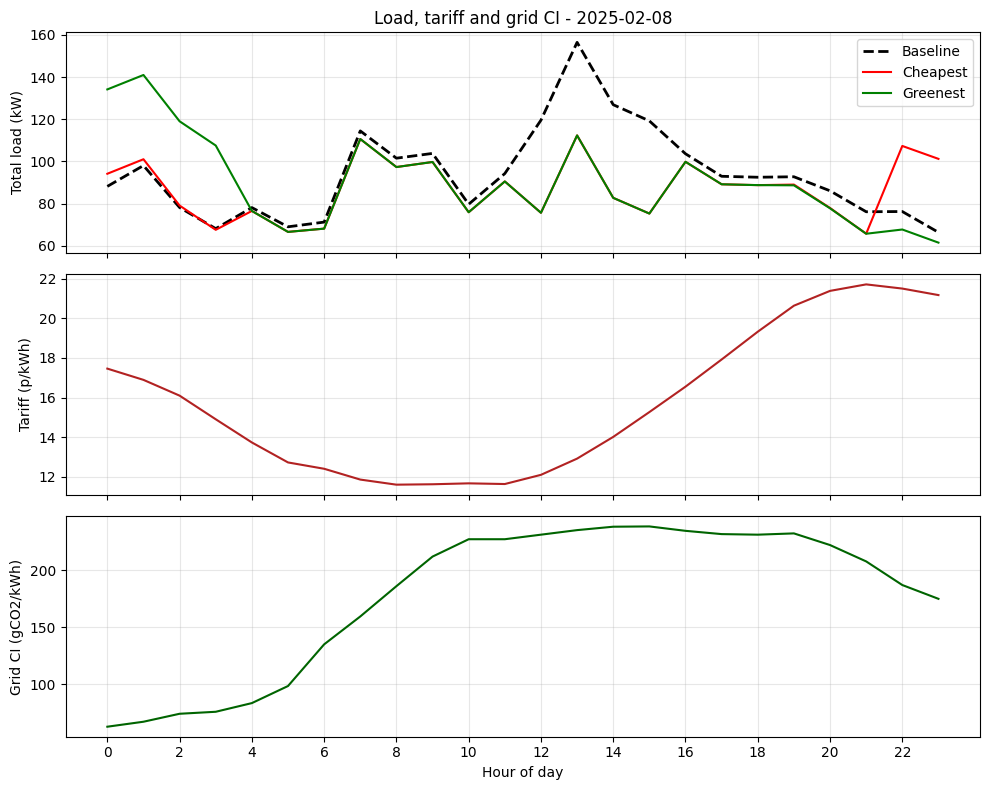

In [ ]:
# Figure 3: load, tariff, grid CI 
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
axes[0].plot(hrs, baseline_total, "k--", lw=2, label="Baseline")
axes[0].plot(hrs, base_kw + hvac_load_kw(res.X[idx_cheap][:24]) + theatre_kw
             + mri_kw + deferrable_profile(res.X[idx_cheap][24]),
             "r-", label="Cheapest")
axes[0].plot(hrs, base_kw + hvac_load_kw(res.X[idx_green][:24]) + theatre_kw
             + mri_kw + deferrable_profile(res.X[idx_green][24]),
             "g-", label="Greenest")
axes[0].set_ylabel("Total load (kW)")
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title(f"Load, tariff and grid CI - {TARGET_DATE}")
axes[1].plot(hrs, tariff_p, color="firebrick")
axes[1].set_ylabel("Tariff (p/kWh)"); axes[1].grid(alpha=0.3)
axes[2].plot(hrs, grid_ci, color="darkgreen")
axes[2].set_ylabel("Grid CI (gCO2/kWh)")
axes[2].set_xlabel("Hour of day"); axes[2].grid(alpha=0.3)
axes[2].set_xticks(range(0, 24, 2))
plt.tight_layout()
plt.savefig("baseline_vs_best.png", dpi=150, bbox_inches="tight")
print("Saved baseline_vs_best.png\nDone.")